# Laboratorio 5 - Parte 1. Redes recurrentes

In [1]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/jdariasl/Intro_ML_2025/master/init.py
import init; init.init(force_download=False); init.get_weblink()

In [ ]:
from local.lib.rlxmoocapi import submit, session
import inspect
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L05.01", varname="student");

<IPython.core.display.Javascript object>

In [2]:
#configuración del laboratorio
# Ejecuta esta celda!
from Labs.commons.utils.lab5 import *
_, dataset = part_1()

En este  laboratorio entrenaremos una Red Neuronal Recurrente para la predicción de una serie de tiempo.

Este problema corresponde a una configuración many-to-one.

En este caso usaremos una serie de tiempo que corresponde al número de pasajeros internacionales por mes, desde el año 1949 hasta el año 1960.

En la siguiente celda visualizamos los datos.

Debemos observar el aparente periodo que existe en nuestra variable. ¿cada cuantos meses parece repertirse el patrón de la serie?

tenemos dispnible nuestra base de datos en el pandas DF 'dataset' 



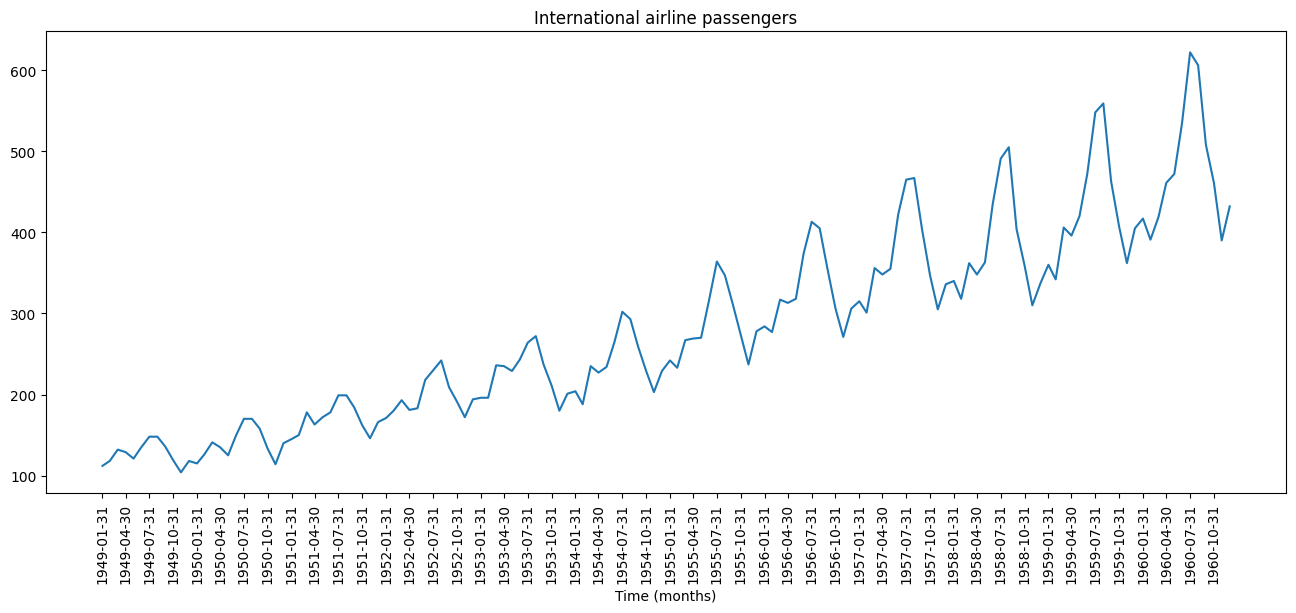

In [3]:
# creamos una variable para
# el tiempo
Time = pd.date_range(np.datetime64('1949-01'), np.datetime64('1961-01'), freq='M')
print("tenemos dispnible nuestra base de datos en el pandas DF 'dataset' \n")
fig, ax = plt.subplots(figsize = (16,6))
ax.plot(Time,dataset)
ax.set_title('International airline passengers')
ax.set_xlabel('Time (months)')
ax.set_xticks( pd.date_range(np.datetime64('1949-01'), np.datetime64('1961-01'), freq='3M'))
plt.xticks(rotation=90)
plt.show()

En nuestro primer ejercicio vamos a explorar, el patrón que observamos en la grafica anterior. Esto tambien nos puede decir qué relación existe entre una muestra en el tiempo $t$ con las muestras anteriores.

La libreria statsmodel [tiene una función que nos sirve para analizar esta relación](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html).


## Ejercicio 1 - Exploración del problema

Este plot realiza una operación cuyos detalles son explicados en mayor profundidad en [esta buena entrada de blog](https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/). Pero en este laboratorio lo que no interesa entender es:

1. El valor varia entre 1.0 y -1.0.
2. Cuando el valor de la correlación es 1.0, corresponde el valor maximo indicando una relación positiva entre la variable y su correspondiente lag o retraso.
3. Cuando el valor de la correlación es -1.0, corresponde el valor mínimo indicando una relación negativa entre la variable y su correspondiente lag o retraso..
4. 0.0 indica que los valores no están relacionados.
5. el lag indica, el número de retrasos. Si el valor de la correlación en el lag  5 es igual 0.75, indica una relación positiva alta entre el actaul y el quinto retraso anterior en la mayoria de muestras de nuestra variable de respuesta.

Ahora, grafiquemos la correlación para un maximo de 36 lags de nuestros datos. Esto significa que estamos analizando las relación de una muestras respecto a la 36 muestras pasdas.

Sabiendo que nuestro eje X representa los meses y nuestro eje y representan el numero de pasajeros. Al realizar el analisis de lags estamos determinando si el número de pasajeros de los meses pasados tiene influencia en el nuúmero de pasajeros en el mes acutal.

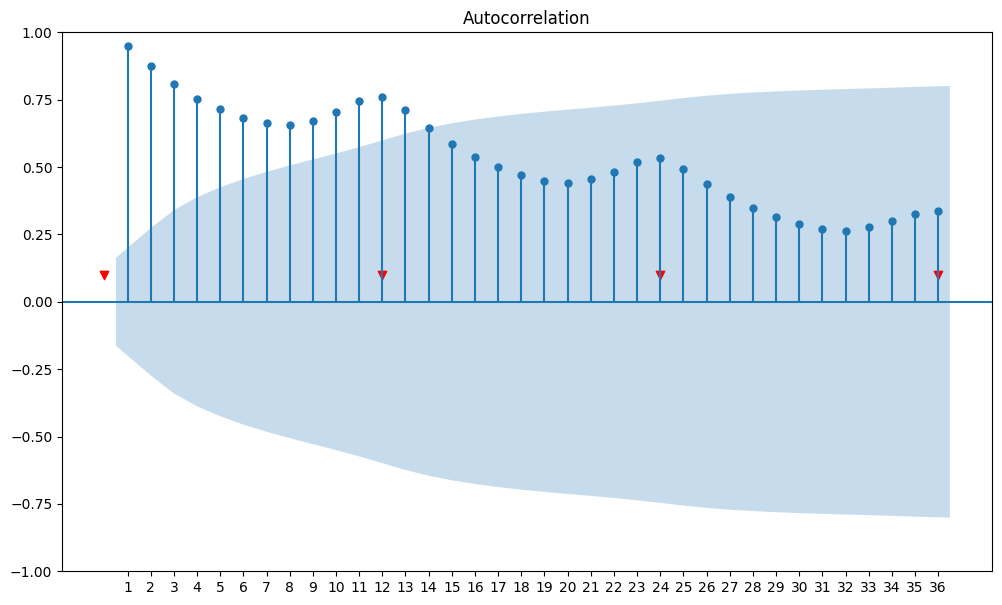

In [4]:
from statsmodels.graphics import tsaplots
fig, ax = plt.subplots(figsize = (12,7))
# Display the autocorrelation plot of your time series
fig = tsaplots.plot_acf(dataset.passengers, lags=range(1,37), ax = ax)
ax.set_xticks( range(1,37))
ax.scatter(range(0,37,12), 0.1*np.ones(4), c = 'r', marker = "v")
plt.show()

reforzando el entendimiento, observando la grafica anterior:

1. Cuando hay un lag = 5 (es decir se evalúa qué tan relacionadas están las 5 muestras anteriores), tenemos una autocorrelación $\approx$ 0.75
2. Cuando hay un lag = 25 (es decir se evalúa qué tan relacionadas están las 25 muestras anteriores), tenemos una autocorrelación $\approx$ 0.5
3. Presta atención al patrón que se resalta con las marcas rojas

Vamos a observar estas relaciones viendo cómo los picos de correlación se relacionan con los patrones que vemos. A continuación, graficamos los valores de autocorrelación junto con la serie de los valores reales.

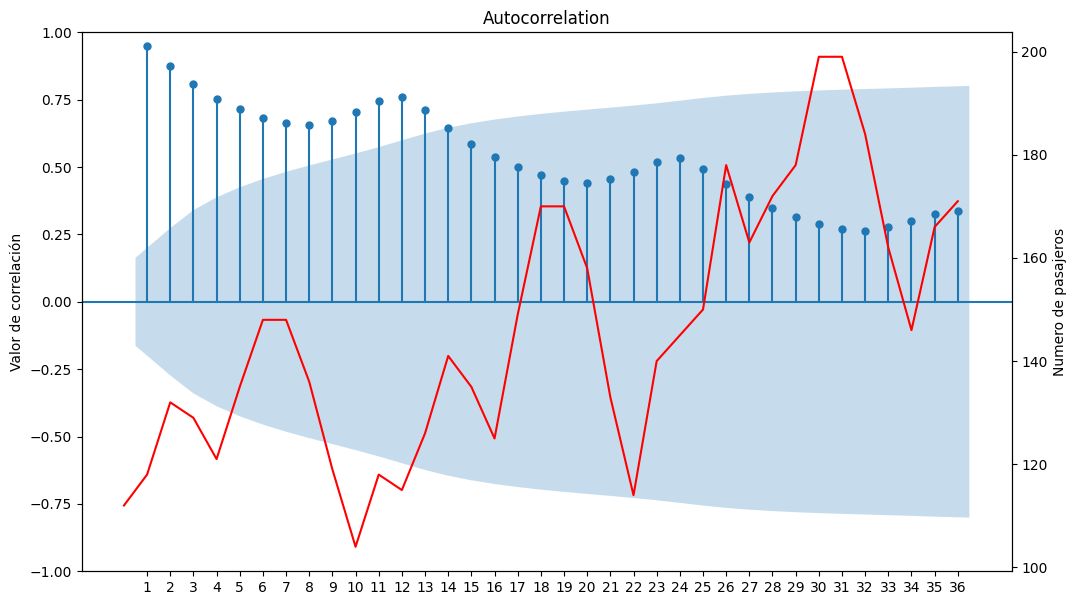

In [5]:
fig, ax = plt.subplots(figsize = (12,7))
# Display the autocorrelation plot of your time series
fig = tsaplots.plot_acf(dataset.passengers, lags=range(1,37), ax = ax)
ax.set_xticks( range(1,37))
ax.set_ylabel("Valor de correlación")
ax2 = ax.twinx()
ax2.set_ylabel("Numero de pasajeros")
ax2.plot(dataset[0:37], c = 'r')
plt.show()

Ahora bien, para poder aplicar una RNN, debemos transformar los datos. Observa la figura, para entender como debemos transformar los datos.

![rnn](https://raw.githubusercontent.com/jdariasl/ML_2020/master/Labs/commons/images/UDEA%20-%20RNN.jpg)

Con base en el análisis de correlación que reveló cómo están  relacionadas la muestra actual y las anteriores y teniendo en cuenta que la preparación de los datos consiste en usar las muestras pasadas para predicir la muestra siguiente. Responde la siguiente pregunta.

In [ ]:
#@title Pregunta Abierta
#@markdown ¿Cual podría ser el número máximo de muestras pasadas para transformar el conjunto de datos?
respuesta = "" #@param {type:"string"}

Ahora, realicemos el ejercicio de transformar nuestros datos a la forma requerida.

In [ ]:
#ejercicio de codigo
def create_dataset(dataset, look_back=1):
    """función que crea dataset apto para RNN

    dataset: matriz numpy con el conjunto de datos
    look_back: número de retrasos con los cuales queremos construir
        las características

    Retorna:
      X: un numpy array con los valores de entrada a la red (debe ser una matrix)
      Y: un numpy array con los valores de salida deseada de la red
    """


    return X, Y

In [229]:
## TEACHER
from local.lib.rlxmoocapi import submit, session
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L05.01", varname="teacher");

logging in as julian.ariasl@udea.edu.co... please wait

-------------
using course session introml::udea.pre.20251
success!! you are logged in
-------------


In [ ]:
teacher = session.Session(init.endpoint).login(course_id=init.course_id, lab_id='L05.01', google_token=google_token)

In [ ]:
## TEACHER DEFINEGRADER
def grader_01(functions, variables, caller_userid):
    import numpy as np
    from sklearn.neural_network import MLPRegressor

    def t_create_dataset(dataset, look_back=1):
      """función que crea dataset apto para RNN

      dataset: matriz numpy con el conjunto de datos
      look_back: numero de retrasos con los cuales queremos construir
          las características

      Retorna:
        X: un numpy array con los valores de entrada a la red (debe ser una matrix)
        Y: un numpy array con los valores de salida deseada de la red
      """
      dataset = dataset.reshape(-1,1)
      dataX, dataY = [], []
      for i in range(len(dataset)-look_back-1):
          a = dataset[i:(i+look_back), 0]
          dataX.append(a)
          dataY.append(dataset[i + look_back, 0])
      return np.stack(dataX), np.array(dataY)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_create_dataset = namespace['create_dataset']

    msg = "testing your code with 100 random data points<br/>"

    for _ in range(5):

      input_lack = np.random.randint(5)+1
      input_length = np.random.randint(500) + 20
      input_data = np.random.randn(input_length)

      t_X, t_y = t_create_dataset(input_data,look_back=input_lack)
      s_X, s_y = s_create_dataset(input_data,look_back=input_lack)

      msg = ""

      if not t_X.shape == s_X.shape:
        msg += f"""
        <b>Incorrect input shape</b>
        For a time, time series length of {input_length}  and a time lack of {input_lack} \n
        Expecting <pre>{t_X.shape}</pre> <br/>
        but got <pre>{s_X.shape}</pre><br/>\n
        """
        return 0, msg

      if not t_y.shape == s_y.shape:
        msg += f"""
        <b>Incorrect output shape</b>
        For a time, time series length of {input_length}  and a time lack of {input_lack} \n
        Expecting <pre>{t_y.shape}</pre> <br/>
        but got <pre>{s_y.shape}</pre><br/>\n
        """
        return 0, msg

      if not (t_X == s_X).any():
        msg += f"""
        <b>Incorrect input data configuration</b>
        For a time, time series {input_data} and a time lack of {input_lack} \n
        Expecting input data <pre>{t_X}</pre> <br/>
        but got <pre>{s_X}</pre><br/>\n
        """
        return 0, msg

      if not (t_y == s_y).any():
        msg += f"""
        <b>Incorrect output data configuration</b>
        For a time, time series {input_data} and a time lack of {input_lack} \n
        Expecting output data <pre>{t_y}</pre> <br/>
        but got <pre>{s_y}</pre><br/>\n
        """
        return 0, msg


      return 5, msg+'<b>correct</b>'
source_functions_names_01 = ['create_dataset']
source_variables_names_01 = []

In [7]:
# TEACHER
def create_dataset(dataset, look_back=1):
    """función que crea dataset apto para RNN

    dataset: matriz numpy con el conjunto de datos
    look_back: número de retrasos con los cuales queremos construir
        las características

    Retorna:
      X: un numpy array con los valores de entrada a la red (debe ser una matrix)
      Y: un numpy array con los valores de salida deseada de la red
    """
    dataset = dataset.reshape(-1,1)

    dataX, dataY = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.stack(dataX), np.array(dataY)

In [ ]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_01", source_functions_names_01, source_variables_names_01, locals())

In [ ]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L05.01", 'T1',
                  inspect.getsource(grader_01), 'grader_01',
                  source_functions_names_01, source_variables_names_01)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T1');

In [8]:
# observemos el funcionamiento de nuestra funcion
x_to_see, y_to_see =  create_dataset(dataset.values, 3)
display("primeras muestras de x", x_to_see[0:3])
display("primeras muestras de y", y_to_see[0:3])

'primeras muestras de x'

array([[112, 118, 132],
       [118, 132, 129],
       [132, 129, 121]])

'primeras muestras de y'

array([129, 121, 135])

## Ejercicio 2 - Crear una RNN

Al igual que en laboratorio anterior, vamos a usar [PyTorch](https://pytorch.org/) para diseñar y construir las redes neuronales con las que vamos a experimentar.

En el siguiente ejercicio vamos a crear una función para construir una RNN usando la libreria mencionada.  Deben revisar con detenimiento la documentación de las capas tipo [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html).

In [ ]:
# ejercicio de código
# Vamos a crear una red neuronal recurrente. En este caso no podemos usar el módulo
# nn.Sequential porque las capas RNN retornan dos salidas y es necesario, según el
# diseño de la arquitectura, decidir cómo usarlas.

def create_rnn_model(num_hidden_neurons):
    import torch.nn as nn
    """función que crea un modelo RNN
    La arquitectura de la red RNN debe estar compuesta de dos capas:
      1. Una capa RNN (tener en cuenta el número de neuronas ocultas,
         como vamos a modelar una serie temporal unidimensional, el número de características es 1)
      2. Una capa Densa (Linear) de salida

    parametros
      num_hidden_neurons (int): número neuronas en la capa oculta

    retorna nn.Module con la red neuronal
    """

    class Recurrent_NN(nn.Module):
      def __init__(self, num_hidden_neurons):
          super().__init__()
          self.rnn = ...
          self.linear =...

      #Este método define el fluje de información a través del modelo
      def forward(self, x):
          _, h = self.rnn(x)
          x = h.squeeze()
          x = self.linear(x)
          return x

    return Recurrent_NN(num_hidden_neurons)


In [174]:
## TEACHER DEFINEGRADER
def grader_02(functions, variables, caller_userid):
    import numpy as np
    import torch.nn as nn
    import torch

    def t_create_rnn_model(num_hidden_neurons):
        """función que crea un modelo RNN que usa mean_absolute_error
        como funcion de perdida
        La arquitectura de RNN que debe estar compuesta de dos capas:
          1. Una capa RNN (tener en cuenta el número de neuronas ocultas,
             como vamos a modelar una serie temporal unidimensional, el número de características es 1)
          2. Una capa Densa (Linear)

        parametros
          num_hidden_neurons (int): número neuronas en la capa oculta

        retorna nn.Module con la red neuronal
        """

        class Recurrent_NN(nn.Module):
          def __init__(self,num_hidden_neurons):
              super().__init__()
              self.rnn = nn.RNN(input_size = 1, hidden_size = num_hidden_neurons, num_layers = 1, batch_first = True)
              self.linear = nn.Linear(num_hidden_neurons, 1)

          def forward(self, x):
              _, h = self.rnn(x)
              x = h.squeeze()
              x = self.linear(x)
              return x

        return Recurrent_NN(num_hidden_neurons)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_create_rnn_model = namespace['create_rnn_model']
    create_dataset = namespace['create_dataset']

    msg =  "testing your code with random data points<br/>\n"

    for _ in range(5):  # Puedes ajustar el número de iteraciones según sea necesario
        input_lack = np.random.randint(5)+1
        input_length = np.random.randint(500) + 20
        input_data = np.random.randn(input_length)
        neurons = np.random.randint(10)+2

        X, _ = create_dataset(input_data,look_back=input_lack)
        X = torch.from_numpy(X).float()
        X = X.unsqueeze(2)
        torch.manual_seed(0)
        np.random.seed(0)
        t_modelo = t_create_rnn_model(neurons)
        l_t = [module for module in t_modelo.modules()]

        torch.manual_seed(0)
        np.random.seed(0)
        s_modelo = s_create_rnn_model(neurons)
        l_s = [module for module in s_modelo.modules()]

        if len(l_t) != len(l_s):
            msg += f"""
            <b>Incorrect model architecture</b>
            Expecting <pre>{len(t_modelo)}</pre> layers <br/>
            but got <pre>{len(s_modelo)}</pre><br/>
            Check model construction setting\n
            """
            return 0, msg


        if l_t[1].input_size != l_s[1].input_size:
            msg += f"""
            <b>Incorrect model architecture</b>
            For a time, lack of {input_lack} and {neurons} neurons \n
            Expecting input dim for RNN layer =  <pre>{t_modelo[0].input_size}</pre> <br/>
            but got <pre>{s_modelo[0].input_size}</pre><br/>
            Check hyperparameter setting\n
            """
            return 0, msg

        if l_t[2].out_features != l_s[2].out_features:
            msg += f"""
             <b>Incorrect model architecture</b>
            For a time, lack of {input_lack} and {neurons} neurons \n
            Expecting output dim =  <pre>{t_modelo[1].out_features}</pre> <br/>
            but got <pre>{s_modelo[1].out_features}</pre><br/>
            Check hyperparameter setting\n
            """
            return 0, msg

        s_salida = s_modelo(X)
        t_salida = t_modelo(X)
        if not torch.allclose(t_salida, s_salida):
            msg += f"""
            <b>Incorrect model output</b>
            Expecting output <pre>{t_salida}</pre> <br/>
            but got <pre>{s_salida}</pre><br/>
            Check model construction\n
            """
            return 0, msg


    return 5, msg + '<b>correct</b> ✅'

source_functions_names_02 = ['create_rnn_model','create_dataset']
source_variables_names_02 = []

In [175]:
# TEACHER


def create_rnn_model(num_hidden_neurons):
    import torch.nn as nn
    """función que crea un modelo RNN que usa mean_absolute_error
    como funcion de perdida
    La arquitectura de RNN que debe estar compuesta de dos capas:
      1. Una capa RNN (tener en cuenta el número de neuronas ocultas,
         como vamos a modelar una serie temporal unidimensional, el número de características es 1)
      2. Una capa Densa (Linear)

    parametros
      num_hidden_neurons (int): número neuronas en la capa oculta

    retorna nn.Module con la red neuronal
    """

    class Recurrent_NN(nn.Module):
      def __init__(self, num_hidden_neurons):
          super().__init__()
          self.rnn = nn.RNN(input_size = 1, hidden_size = num_hidden_neurons, num_layers = 1, batch_first = True)
          self.linear = nn.Linear(num_hidden_neurons, 1)

      def forward(self, x):
          _, h = self.rnn(x)
          x = h.squeeze()
          x = self.linear(x)
          return x

    return Recurrent_NN(num_hidden_neurons)

In [176]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_02", source_functions_names_02, source_variables_names_02, locals())

In [179]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L05.01", 'T2',
                  inspect.getsource(grader_02), 'grader_02',
                  source_functions_names_02, source_variables_names_02)

**Registra tu solución en línea**

In [95]:
student.submit_task(namespace=globals(), task_id='T2');

NameError: name 'student' is not defined

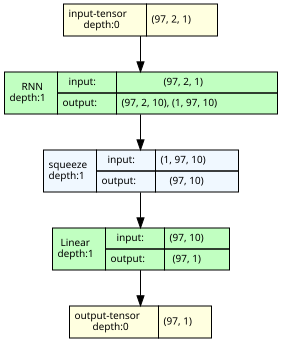

In [182]:
#Grafiquemos las arquitecturas de dos modelos con parámetros diferentes:

import torch
from torchview import draw_graph
input_data = np.random.randn(100)
look_back = 2
X, _ = create_dataset(input_data,look_back=look_back)
X = torch.from_numpy(X).float()
# Una capa RNN recibe entradas de dimensión (B,T,D). En realidad queremos que los
# retardos sean entendidos como muestras pasadas (Tiempos), por lo tanto agregamos
# una dimensión al final para que el modelo lea los datos como valores pasados de 1
# dimensión.
X = X.unsqueeze(2)
model =  create_rnn_model(num_hidden_neurons = 10)
model_graph = draw_graph(model, input_size=X.shape)
model_graph.visual_graph

In [90]:
X.shape

torch.Size([97, 2, 1])

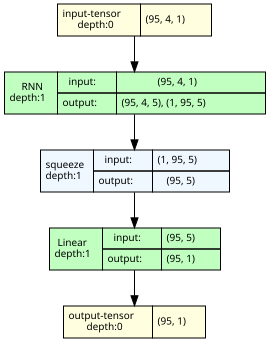

In [183]:
look_back = 4
X, _ = create_dataset(input_data,look_back=look_back)
X = torch.from_numpy(X).float()
X = X.unsqueeze(2)
model =  create_rnn_model(num_hidden_neurons = 5)
model_graph = draw_graph(model, input_size=X.shape)
model_graph.visual_graph

## Ejercicio 3: Experimentar con RNN

Con nuestra función que crea modelos, vamos experimentar variando los dos parametros:

- número de retrasos
- número de neuronas en la capa oculta

Otras condiciones:
- Vamos a dejar fijo el # de epocas 50.
- Usaremos la métrica MAE (ver [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html))
- Revise con cuidado el tamaño de la


In [198]:
#ejercicio de código
def experimentar_rnn(data, look_backs, hidden_neurons):
    """función que realiza experimentos para evaluar una RNN de elman usando
        el error absoluto medio como medida de error

    data: pd.Dataframe, dataset a usar
    look_back: List[int], lista con los número de retrasos a evaluar
    hidden_neurons: List[int], list con el número de neuronas en la capa oculta
    retorna: pd.Dataframe con las siguientes columnas:
        - lags
        - neuronas por capas
        - error de entrenamiento
        - error de prueba
    """
    # Normalizar
    scaler = MinMaxScaler(feature_range=(0, 1))
    dataset = scaler.fit_transform(data)
    # realizar el split
    train_size = int(len(dataset) * 0.7)
    test_size = len(dataset) - train_size
    train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
    resultados = pd.DataFrame()
    idx = 0
    for num_hidden_neurons in hidden_neurons:
        for look_back in look_backs:
            # aplicar la transformación creada antes
            trainX, trainY = ...
            trainX = torch.from_numpy(trainX).float()
            trainY = torch.from_numpy(trainY).float()
            trainX = trainX.unsqueeze(2)

            testX, testY = ...
            testX = torch.from_numpy(testX).float()
            testX = testX.unsqueeze(2)

            # creemos el modelo
            model = ...
            # Defina la función de coste de mean absolute error en PyTorch
            loss = torch.nn...
            optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

            #Entrenaremos el modelo por 50 epocas
            for epoch in range(50):
                model.train()

                optimizer.zero_grad()
                trainYPred = model(trainX)
                trainLoss = loss(trainYPred, trainY)
                trainLoss.backward()
                optimizer.step()

            # Obtener las predicciones del modelo
            model.eval()
            trainYPred  = ...
            testYPred = ...
            #Use la métrica de error absoluto medio de sklearn
            #Note que usamos el método detach() para poder usar la función de sklearn
            errorEntrenamiento = ...(trainY.detach().numpy(), trainYPred.detach().numpy())
            errorPrueba = ...(testY,  testYPred.detach().numpy())
            resultados.loc[idx,'lags'] = look_back
            resultados.loc[idx,'neuronas por capa'] = ...
            resultados.loc[idx,'error de entrenamiento'] = ...
            resultados.loc[idx,'error de prueba'] = ...
            idx+=1
            print("termina para", look_back, num_hidden_neurons)

    return (resultados)

SyntaxError: invalid syntax (<ipython-input-198-0ea00f773625>, line 40)

In [218]:
## TEACHER DEFINEGRADER
def grader_03(functions, variables, caller_userid):
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error
    import torch
    import torch.nn as nn

    def t_experimentar_rnn(data, look_backs, hidden_neurons):
        """función que realiza experimentos para evaluar una RNN de elman usando
            el error absoluto medio como medida de error

        data: pd.Dataframe, dataset a usar
        look_back: List[int], lista con los número de retrasos a evaluar
        hidden_neurons: List[int], list con el número de neuronas en la capa oculta
        retorna: pd.Dataframe con las siguientes columnas:
            - lags
            - neuronas por capas
            - error de entrenamiento
            - error de prueba
        """
        # Normalizar
        scaler = MinMaxScaler(feature_range=(0, 1))
        dataset = scaler.fit_transform(data)
        # realizar el split
        train_size = int(len(dataset) * 0.7)
        test_size = len(dataset) - train_size
        train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
        resultados = pd.DataFrame()
        idx = 0
        for num_hidden_neurons in hidden_neurons:
            for look_back in look_backs:
                # aplicar la transformacion
                trainX, trainY = create_dataset(train, look_back)
                trainX = torch.from_numpy(trainX).float()
                trainY = torch.from_numpy(trainY).float().reshape(-1,1)
                trainX = trainX.unsqueeze(2)

                testX, testY = create_dataset(test, look_back)
                testX = torch.from_numpy(testX).float()
                testX = testX.unsqueeze(2)

                # creemos el modelo
                model = create_rnn_model(num_hidden_neurons = num_hidden_neurons)
                # entrenemos el modelo
                loss = nn.L1Loss()
                optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
                for epoch in range(50):
                    model.train()

                    optimizer.zero_grad()
                    trainYPred = model(trainX)
                    trainLoss = loss(trainYPred, trainY)
                    trainLoss.backward()
                    optimizer.step()

                # predecimos en los conjuntos
                model.eval()
                trainYPred  = model(trainX)
                testYPred = model(testX)
                errorEntrenamiento = mean_absolute_error(trainY.detach().numpy().reshape(-1,1), trainYPred.detach().numpy().reshape(-1,1))
                errorPrueba = mean_absolute_error(testY.reshape(-1,1),  testYPred.detach().numpy().reshape(-1,1))
                resultados.loc[idx,'lags'] = look_back
                resultados.loc[idx,'neuronas por capa'] = num_hidden_neurons
                resultados.loc[idx,'error de entrenamiento'] = errorEntrenamiento
                resultados.loc[idx,'error de prueba'] = errorPrueba
                idx+=1
                print("termina para", look_back, num_hidden_neurons)

        return (resultados)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_experimentar_rnn = namespace['experimentar_rnn']
    create_rnn_model = namespace['create_rnn_model']
    create_dataset = namespace['create_dataset']

    msg =  "testing your code with random data points<br/>\n"

    for _ in range(1):  # Puedes ajustar el número de iteraciones según sea necesario

        input_lack = np.random.randint(5)+1
        input_length = np.random.randint(500) + 20
        input_data = np.random.randn(input_length)
        neurons = np.random.randint(10, size=3, dtype=int)+2
        neurons = neurons.tolist()
        look_back = np.random.randint(5, size=4)+1
        torch.manual_seed(0)
        np.random.seed(0)

        t_resultados = t_experimentar_rnn(input_data.reshape(-1,1),look_back,neurons).values

        torch.manual_seed(0)
        np.random.seed(0)
        s_resultados = s_experimentar_rnn(input_data.reshape(-1,1),look_back,neurons).values

        if not np.allclose(t_resultados, s_resultados):
            msg += f"""
            <b>Incorrect experiment results</b>
            Expecting result <pre>{t_resultados}</pre> <br/>
            but got <pre>{s_resultados}</pre><br/>
            Check hyperparameter settings\n
            """
            return 0, msg

    return 5, msg + '<b>correct</b> ✅'

source_functions_names_03 = ['experimentar_rnn','create_rnn_model','create_dataset']
source_variables_names_03 = []

In [202]:
# TEACHER

def experimentar_rnn(data, look_backs, hidden_neurons):
    from sklearn.metrics import mean_absolute_error
    """función que realiza experimentos para evaluar una RNN de elman usando
        el error absoluto medio como medida de error

    data: pd.Dataframe, dataset a usar
    look_back: List[int], lista con los número de retrasos a evaluar
    hidden_neurons: List[int], list con el número de neuronas en la capa oculta
    retorna: pd.Dataframe con las siguientes columnas:
        - lags
        - neuronas por capas
        - error de entrenamiento
        - error de prueba
    """
    # Normalizar
    scaler = MinMaxScaler(feature_range=(0, 1))
    dataset = scaler.fit_transform(data)
    # realizar el split
    train_size = int(len(dataset) * 0.7)
    test_size = len(dataset) - train_size
    train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
    resultados = pd.DataFrame()
    idx = 0
    for num_hidden_neurons in hidden_neurons:
        for look_back in look_backs:
            # aplicar la transformacion
            trainX, trainY = create_dataset(train, look_back)
            trainX = torch.from_numpy(trainX).float()
            trainY = torch.from_numpy(trainY).float().reshape(-1,1)
            trainX = trainX.unsqueeze(2)

            testX, testY = create_dataset(test, look_back)
            testX = torch.from_numpy(testX).float()
            testX = testX.unsqueeze(2)

            # creemos el modelo
            model = create_rnn_model(num_hidden_neurons = num_hidden_neurons)
            # entrenemos el modelo
            loss = nn.L1Loss()
            optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
            for epoch in range(50):
                model.train()

                optimizer.zero_grad()
                trainYPred = model(trainX)
                trainLoss = loss(trainYPred, trainY)
                trainLoss.backward()
                optimizer.step()

            # predecimos en los conjuntos
            model.eval()
            trainYPred  = model(trainX)
            testYPred = model(testX)
            errorEntrenamiento = mean_absolute_error(trainY.detach().numpy().reshape(-1,1), trainYPred.detach().numpy().reshape(-1,1))
            errorPrueba = mean_absolute_error(testY.reshape(-1,1),  testYPred.detach().numpy().reshape(-1,1))
            resultados.loc[idx,'lags'] = look_back
            resultados.loc[idx,'neuronas por capa'] = num_hidden_neurons
            resultados.loc[idx,'error de entrenamiento'] = errorEntrenamiento
            resultados.loc[idx,'error de prueba'] = errorPrueba
            idx+=1
            print("termina para", look_back, num_hidden_neurons)

    return (resultados)

In [186]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_03", source_functions_names_03, source_variables_names_03, locals())

termina para 1 5
termina para 3 5
termina para 4 5
termina para 4 5
termina para 1 5
termina para 3 5
termina para 4 5
termina para 4 5
termina para 1 8
termina para 3 8
termina para 4 8
termina para 4 8
termina para 1 5
termina para 3 5
termina para 4 5
termina para 4 5
termina para 1 5
termina para 3 5
termina para 4 5
termina para 4 5
termina para 1 8
termina para 3 8
termina para 4 8
termina para 4 8


In [206]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L05.01", 'T3',
                  inspect.getsource(grader_03), 'grader_03',
                  source_functions_names_03, source_variables_names_03)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T3');

Ahora vamos a ver los resultados del experimentos:

1. variando los lags dejando las neuronas por capa fijas
2. variando las neuronas y dejando los retrasos fijos

experimente con diferentes configuraciones. Por la inicialización aleatorias los resultados pueden cambiar. Preste a los patrones que se van presentando y no a los valores exactos.

termina para 3 15
termina para 9 15
termina para 12 15
termina para 24 15
termina para 30 15
termina para 36 15


Text(0.5, 0.98, 'efecto del # retrasos')

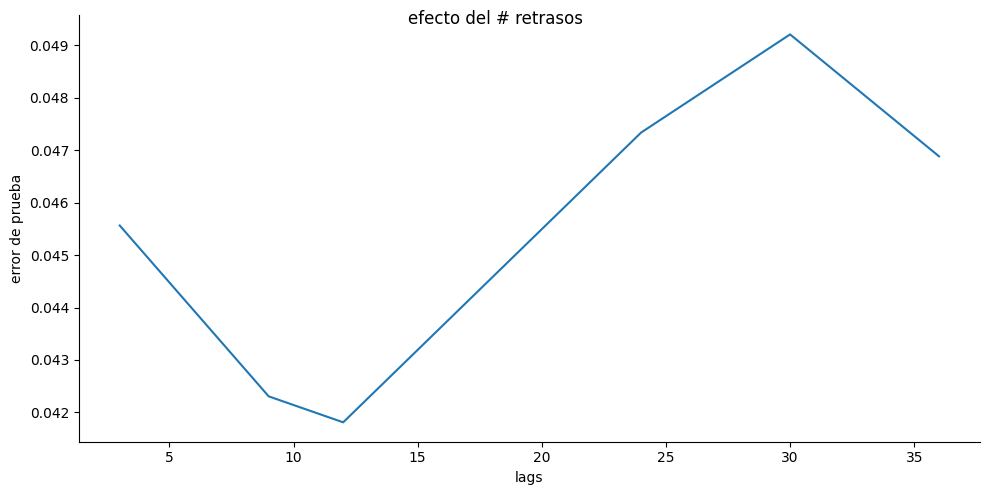

In [195]:
# observa el comportamiento de los lags
import seaborn as sns
import torch.nn as nn
import torch
torch.manual_seed(2)
np.random.seed(2)
resultadosRNN = experimentar_rnn(dataset, look_backs = [3,9,12,24,30,36], hidden_neurons=[15])
# plot
ax1  = sns.relplot(data= resultadosRNN, x= 'lags', y = 'error de prueba', kind = 'line', aspect = 2)
ax1.fig.suptitle('efecto del # retrasos')

termina para 9 5
termina para 9 15
termina para 9 30
termina para 9 60


Text(0.5, 0.98, 'efecto del # neuronas')

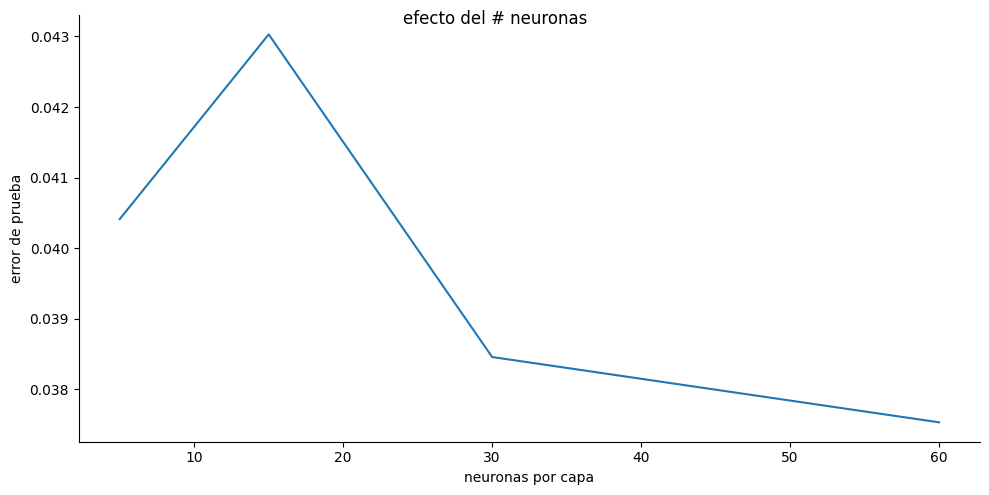

In [196]:
torch.manual_seed(2)
np.random.seed(2)
resultadosRNN = experimentar_rnn(dataset, look_backs = [9], hidden_neurons=[5,15,30,60])
ax2  = sns.relplot(data= resultadosRNN, x= 'neuronas por capa', y = 'error de prueba', kind = 'line', aspect = 2)
ax2.fig.suptitle('efecto del # neuronas')

In [199]:
#@title Pregunta Abierta
#@markdown ¿Por qué seguir aumentando los tiempos de retardo no implica siempre una mejora en la predicción del modelo?
respuesta = "" #@param {type:"string"}

## Ejercicio 4 - Comparación con MLP

En este ejercicio vamos a resolver el mismo problema, pero con un MLP. Con esto vamos a comparar los resultados obtenidos con la RNN.

Seguiremos las siguientes reglas:
1. Variar el número de retrasos, que corresponden en este caso al número de características en la capa de entrada
2. Usaremos solo una capa oculta y evaluaremos diferente número de neuronas en esta capa
3. El número de epocas también se ajustará a 50
4. Usaremos las misma métrica y función de coste empleadas en el ejercicio anterior.

In [ ]:
#ejercicio de código

def create_mlp_model(look_back, num_hidden_neurons):
  ''' función que retorna el modelo MLP con una sola capa oculta con función de activación ReLU
      En este caso se puede volver a hacer uso del módulo nn.Sequential de pytorch
      Recordar el ejercicio 4 del laboratorio 4 parte 1.

      Parametros:
        look_back: número de retrasos que serán usados como características de entrada
        num_hidden_neurons: número de neuronas en la capa oculta
      Retorna:
        nn.Module con el modelo MLP

  '''

  return

def experimentar_MLP(data, look_backs, hidden_neurons):
    """función que realiza experimentos para evaluar una MLP usando
        MAE como medida de error

    data: pd.Dataframe, dataset a usar
    look_back: List[int], lista con los numero de retrasos a evaluar
    hidden_neurons: List[int], list con el numero de neuronas en la capa oculta
    retorna: pd.Dataframe con las siguientes columnas:
        - lags
        - neuronas por capas
        - error de prueba
        - tiempo de entrenamiento
    """
    # we need to normalize the dataset before
    #
    scaler = MinMaxScaler(feature_range=(0, 1))
    dataset = scaler.fit_transform(data)
    # split into train and test sets
    train_size = int(len(dataset) * 0.7)
    test_size = len(dataset) - train_size
    train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
    resultados = pd.DataFrame()
    idx = 0
    for num_hidden_neurons in hidden_neurons:
        for look_back in look_backs:

            trainX, trainY = create_dataset(train, look_back)
            trainX = torch.from_numpy(trainX).float()
            trainY = torch.from_numpy(trainY).float().reshape(-1,1)

            testX, testY = create_dataset(test, look_back)
            testX = torch.from_numpy(testX).float()

           # creemos el modelo MLP
            model = ...
            # Defina la función de coste de mean absolute error en PyTorch
            loss = torch.nn...
            optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

            #Entrenaremos el modelo por 50 epocas
            for epoch in range(50):
                model.train()

                optimizer.zero_grad()
                trainYPred = model(trainX)
                trainLoss = loss(trainYPred, trainY)
                trainLoss.backward()
                optimizer.step()

            # Obtener las predicciones del modelo
            model.eval()
            trainYPred  = ...
            testYPred = ...
            #Use la métrica de error absoluto medio de sklearn
            #Note que usamos el método detach() para poder usar la función de sklearn
            errorEntrenamiento = ...(trainY.detach().numpy(), trainYPred.detach().numpy())
            errorPrueba = ...(testY,  testYPred.detach().numpy())
            resultados.loc[idx,'lags'] = look_back
            resultados.loc[idx,'neuronas por capa'] = ...
            resultados.loc[idx,'error de entrenamiento'] = ...
            resultados.loc[idx,'error de prueba'] = ...
            idx+=1
            print("termina para", look_back, num_hidden_neurons)

    return (resultados)

In [207]:
## TEACHER DEFINEGRADER
def grader_04(functions, variables, caller_userid):
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error
    import torch
    import torch.nn as nn

    def t_create_mlp_model(look_back, num_hidden_neurons):
        ''' función que retorna el modelo el modelo MLP
            En este caso se puede volver a hacer uso del módulo nn.Sequential de pytorch

            Parametros:
              look_back: número de retrasos que serán usados como características de entrada
              num_hidden_neurons: número de neuronas en la capa oculta
            Retorna:
              nn.Module con el modelo MLP

        '''
        model = nn.Sequential(
          nn.Linear(look_back, num_hidden_neurons),
          nn.ReLU(),
          nn.Linear(num_hidden_neurons, 1)
        )

        return model
    def t_experimentar_MLP(data, look_backs, hidden_neurons):
        """función que realiza experimentos para evaluar una MLP usando
            MAE como medida de error

        data: pd.Dataframe, dataset a usar
        look_back: List[int], lista con los numero de retrasos a evaluar
        hidden_neurons: List[int], list con el numero de neuronas en la capa oculta
        retorna: pd.Dataframe con las siguientes columnas:
            - lags
            - neuronas por capas
            - error de prueba
            - tiempo de entrenamiento
        """
        # we need to normalize the dataset before
        #
        scaler = MinMaxScaler(feature_range=(0, 1))
        dataset = scaler.fit_transform(data)
        # split into train and test sets
        train_size = int(len(dataset) * 0.7)
        test_size = len(dataset) - train_size
        train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
        resultados = pd.DataFrame()
        idx = 0
        for num_hidden_neurons in hidden_neurons:
            for look_back in look_backs:

                trainX, trainY = create_dataset(train, look_back)
                trainX = torch.from_numpy(trainX).float()
                trainY = torch.from_numpy(trainY).float().reshape(-1,1)

                testX, testY = create_dataset(test, look_back)
                testX = torch.from_numpy(testX).float()

              # creemos el modelo MLP
                model = t_create_mlp_model(look_back,num_hidden_neurons)
                # Defina la función de coste de mean absolute error en PyTorch
                loss = torch.nn.L1Loss()
                optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

                #Entrenaremos el modelo por 50 epocas
                for epoch in range(50):
                    model.train()

                    optimizer.zero_grad()
                    trainYPred = model(trainX)
                    trainLoss = loss(trainYPred, trainY)
                    trainLoss.backward()
                    optimizer.step()

                # Obtener las predicciones del modelo
                model.eval()
                trainYPred  = model(trainX)
                testYPred = model(testX)
                #Use la métrica de error absoluto medio de sklearn
                #Note que usamos el método detach() para poder usar la función de sklearn
                errorEntrenamiento = mean_absolute_error(trainY.detach().numpy(), trainYPred.detach().numpy())
                errorPrueba = mean_absolute_error(testY,  testYPred.detach().numpy())
                resultados.loc[idx,'lags'] = look_back
                resultados.loc[idx,'neuronas por capa'] = num_hidden_neurons
                resultados.loc[idx,'error de entrenamiento'] = errorEntrenamiento
                resultados.loc[idx,'error de prueba'] = errorPrueba
                idx+=1
                print("termina para", look_back, num_hidden_neurons)

        return (resultados)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_experimentar_MLP = namespace['experimentar_MLP']
    create_mlp_model = namespace['create_mlp_model']
    create_dataset = namespace['create_dataset']

    msg =  "testing your code with random data points<br/>\n"

    for _ in range(1):  # Puedes ajustar el número de iteraciones según sea necesario

        input_lack = np.random.randint(5)+1
        input_length = np.random.randint(500) + 20
        input_data = np.random.randn(input_length)
        neurons = np.random.randint(10, size=3, dtype=int)+2
        neurons = neurons.tolist()
        look_back = np.random.randint(5, size=4)+1
        torch.manual_seed(0)
        np.random.seed(0)

        l = np.random.choice(look_back)
        n = np.random.choice(neurons)

        torch.manual_seed(0)
        np.random.seed(0)
        t_model = t_create_mlp_model(l,n)

        torch.manual_seed(0)
        np.random.seed(0)
        s_model = create_mlp_model(l,n)

        trainX, _ = create_dataset(input_data, l)
        trainX = torch.from_numpy(trainX).float()

        t_output = t_model(trainX)
        s_output = s_model(trainX)

        if not torch.allclose(t_output, s_output):
            msg += f"""
            <b>Incorrect model output</b>
            Expecting output <pre>{t_output}</pre> <br/>
            but got <pre>{s_output}</pre><br/>
            Check model construction\n
            """
            return 0, msg

        torch.manual_seed(0)
        np.random.seed(0)
        t_resultados = t_experimentar_MLP(input_data.reshape(-1,1),look_back,neurons).values

        torch.manual_seed(0)
        np.random.seed(0)
        s_resultados = s_experimentar_MLP(input_data.reshape(-1,1),look_back,neurons).values

        if not np.allclose(t_resultados, s_resultados):
            msg += f"""
            <b>Incorrect experiment results</b>
            Expecting result <pre>{t_resultados}</pre> <br/>
            but got <pre>{s_resultados}</pre><br/>
            Check hyperparameter settings\n
            """
            return 0, msg

    return 5, msg + '<b>correct</b> ✅'

source_functions_names_04 = ['experimentar_MLP','create_mlp_model','create_dataset']
source_variables_names_04 = []

In [208]:
#TEACHER

def create_mlp_model(look_back, num_hidden_neurons):
  ''' función que retorna el modelo el modelo MLP
      En este caso se puede volver a hacer uso del módulo nn.Sequential de pytorch

      Parametros:
        look_back: número de retrasos que serán usados como características de entrada
        num_hidden_neurons: número de neuronas en la capa oculta
      Retorna:
        nn.Module con el modelo MLP

  '''
  model = nn.Sequential(
    nn.Linear(look_back, num_hidden_neurons),
    nn.ReLU(),
    nn.Linear(num_hidden_neurons, 1)
  )

  return model

def experimentar_MLP(data, look_backs, hidden_neurons):
    """función que realiza experimentos para evaluar una MLP usando
        MAE como medida de error

    data: pd.Dataframe, dataset a usar
    look_back: List[int], lista con los numero de retrasos a evaluar
    hidden_neurons: List[int], list con el numero de neuronas en la capa oculta
    retorna: pd.Dataframe con las siguientes columnas:
        - lags
        - neuronas por capas
        - error de prueba
        - tiempo de entrenamiento
    """
    # we need to normalize the dataset before
    #
    scaler = MinMaxScaler(feature_range=(0, 1))
    dataset = scaler.fit_transform(data)
    # split into train and test sets
    train_size = int(len(dataset) * 0.7)
    test_size = len(dataset) - train_size
    train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
    resultados = pd.DataFrame()
    idx = 0
    for num_hidden_neurons in hidden_neurons:
        for look_back in look_backs:

            trainX, trainY = create_dataset(train, look_back)
            trainX = torch.from_numpy(trainX).float()
            trainY = torch.from_numpy(trainY).float().reshape(-1,1)

            testX, testY = create_dataset(test, look_back)
            testX = torch.from_numpy(testX).float()

           # creemos el modelo MLP
            model = create_mlp_model(look_back,num_hidden_neurons)
            # Defina la función de coste de mean absolute error en PyTorch
            loss = torch.nn.L1Loss()
            optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

            #Entrenaremos el modelo por 50 epocas
            for epoch in range(50):
                model.train()

                optimizer.zero_grad()
                trainYPred = model(trainX)
                trainLoss = loss(trainYPred, trainY)
                trainLoss.backward()
                optimizer.step()

            # Obtener las predicciones del modelo
            model.eval()
            trainYPred  = model(trainX)
            testYPred = model(testX)
            #Use la métrica de error absoluto medio de sklearn
            #Note que usamos el método detach() para poder usar la función de sklearn
            errorEntrenamiento = mean_absolute_error(trainY.detach().numpy(), trainYPred.detach().numpy())
            errorPrueba = mean_absolute_error(testY,  testYPred.detach().numpy())
            resultados.loc[idx,'lags'] = look_back
            resultados.loc[idx,'neuronas por capa'] = num_hidden_neurons
            resultados.loc[idx,'error de entrenamiento'] = errorEntrenamiento
            resultados.loc[idx,'error de prueba'] = errorPrueba
            idx+=1
            print("termina para", look_back, num_hidden_neurons)

    return (resultados)

In [217]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_04", source_functions_names_04, source_variables_names_04, locals())

termina para 2 4
termina para 3 4
termina para 4 4
termina para 2 4
termina para 2 5
termina para 3 5
termina para 4 5
termina para 2 5
termina para 2 6
termina para 3 6
termina para 4 6
termina para 2 6
termina para 2 4
termina para 3 4
termina para 4 4
termina para 2 4
termina para 2 5
termina para 3 5
termina para 4 5
termina para 2 5
termina para 2 6
termina para 3 6
termina para 4 6
termina para 2 6


In [216]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L05.01", 'T4',
                  inspect.getsource(grader_04), 'grader_04',
                  source_functions_names_04, source_variables_names_04)

**Registra tu solución en línea**

In [215]:
student.submit_task(namespace=globals(), task_id='T4');

NameError: name 'student' is not defined

In [211]:
resultadosMLP = experimentar_MLP(dataset, look_backs = [3,9,12,24,30,36], hidden_neurons=[10,20,30])

termina para 3 10
termina para 9 10
termina para 12 10
termina para 24 10
termina para 30 10
termina para 36 10
termina para 3 20
termina para 9 20
termina para 12 20
termina para 24 20
termina para 30 20
termina para 36 20
termina para 3 30
termina para 9 30
termina para 12 30
termina para 24 30
termina para 30 30
termina para 36 30


In [212]:
# para ver los resultados
# en esta instrucción se va resaltar el menor error
resultadosMLP.style.highlight_min(color = 'green', axis = 0, subset = ['error de prueba'])

,lags,neuronas por capa,error de entrenamiento,error de prueba
0,3.000000,10.000000,0.040508,0.080731
1,9.000000,10.000000,0.040254,0.094265
2,12.000000,10.000000,0.019355,0.048416
3,24.000000,10.000000,0.021992,0.046670
4,30.000000,10.000000,0.041063,0.096673
5,36.000000,10.000000,0.035581,0.087671
6,3.000000,20.000000,0.038240,0.096737
7,9.000000,20.000000,0.042560,0.101604
8,12.000000,20.000000,0.022736,0.049948
9,24.000000,20.000000,0.020391,0.051296


### Ejercicio 5 - Construcción de modelo LSTM

En nuestro ultimo ejercicio, vamos a crear una arquitectura de red con una capa LSTM en lugar de una capa RNN. (Ver la documentación de PyTorch sobre este tipo de capas [link](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)).



In [213]:
#@title Pregunta Abierta
#@markdown ¿Por qué una red LSTM puede ser más adecuada para resolver este problema?
respuesta = "" #@param {type:"string"}

Aca creamos el modelo LSTM usando tensorflow:

In [ ]:
#ejercicio de código

def create_lstm_model(num_hidden_neurons):
    import torch.nn as nn
    """función que crea un modelo LSTM
    La arquitectura de la red LSTM debe estar compuesta de dos capas:
      1. Una capa LSTM (tener en cuenta el número de neuronas ocultas,
         como vamos a modelar una serie temporal unidimensional, el número de características es 1)
      2. Una capa Densa (Linear) de salida

    parametros
      num_hidden_neurons (int): número neuronas en la capa oculta

    retorna nn.Module con la red neuronal
    """

    class LSTM_net(nn.Module):
      def __init__(self, num_hidden_neurons):
          super().__init__()
          self.lstm = ...
          self.linear =...

      #Este método define el fluje de información a través del modelo
      def forward(self, x):

          return

    return LSTM_net(num_hidden_neurons)

In [225]:
## TEACHER DEFINEGRADER
def grader_05(functions, variables, caller_userid):
    import numpy as np
    import torch.nn as nn
    import torch

    def t_create_lstm_model(num_hidden_neurons):
        """función que crea un modelo LSTM
        La arquitectura de la red LSTM debe estar compuesta de dos capas:
          1. Una capa LSTM (tener en cuenta el número de neuronas ocultas,
            como vamos a modelar una serie temporal unidimensional, el número de características es 1)
          2. Una capa Densa (Linear) de salida

        parametros
          num_hidden_neurons (int): número neuronas en la capa oculta

        retorna nn.Module con la red neuronal
        """

        class LSTM_net(nn.Module):
          def __init__(self, num_hidden_neurons):
              super().__init__()
              self.lstm = nn.LSTM(input_size=1, hidden_size=num_hidden_neurons, batch_first=True)
              self.linear = nn.Linear(in_features=num_hidden_neurons, out_features=1)

          #Este método define el fluje de información a través del modelo
          def forward(self, x):
              _, x = self.lstm(x)
              return self.linear(x[0])

        return LSTM_net(num_hidden_neurons)

    # retrieve definitions
    namespace = locals()
    for f in functions.values():
        exec(f, namespace)

    s_create_lstm_model = namespace['create_lstm_model']
    create_dataset = namespace['create_dataset']

    msg =  "testing your code with random data points<br/>\n"

    for _ in range(5):  # Puedes ajustar el número de iteraciones según sea necesario
        input_lack = np.random.randint(5)+1
        input_length = np.random.randint(500) + 20
        input_data = np.random.randn(input_length)
        neurons = np.random.randint(10)+2

        X, _ = create_dataset(input_data,look_back=input_lack)
        X = torch.from_numpy(X).float()
        X = X.unsqueeze(2)
        torch.manual_seed(0)
        np.random.seed(0)
        t_modelo = t_create_lstm_model(neurons)
        l_t = [module for module in t_modelo.modules()]

        torch.manual_seed(0)
        np.random.seed(0)
        s_modelo = s_create_lstm_model(neurons)
        l_s = [module for module in s_modelo.modules()]

        if len(l_t) != len(l_s):
            msg += f"""
            <b>Incorrect model architecture</b>
            Expecting <pre>{len(t_modelo)}</pre> layers <br/>
            but got <pre>{len(s_modelo)}</pre><br/>
            Check model construction setting\n
            """
            return 0, msg


        if l_t[1].input_size != l_s[1].input_size:
            msg += f"""
            <b>Incorrect model architecture</b>
            For a time, lack of {input_lack} and {neurons} neurons \n
            Expecting input dim for RNN layer =  <pre>{t_modelo[0].input_size}</pre> <br/>
            but got <pre>{s_modelo[0].input_size}</pre><br/>
            Check hyperparameter setting\n
            """
            return 0, msg

        if l_t[2].out_features != l_s[2].out_features:
            msg += f"""
             <b>Incorrect model architecture</b>
            For a time, lack of {input_lack} and {neurons} neurons \n
            Expecting output dim =  <pre>{t_modelo[1].out_features}</pre> <br/>
            but got <pre>{s_modelo[1].out_features}</pre><br/>
            Check hyperparameter setting\n
            """
            return 0, msg

        s_salida = s_modelo(X)
        t_salida = t_modelo(X)
        if not torch.allclose(t_salida, s_salida):
            msg += f"""
            <b>Incorrect model output</b>
            Expecting output <pre>{t_salida}</pre> <br/>
            but got <pre>{s_salida}</pre><br/>
            Check model construction\n
            """
            return 0, msg


    return 5, msg + '<b>correct</b> ✅'

source_functions_names_05 = ['create_lstm_model','create_dataset']
source_variables_names_05 = []

In [226]:
#TEACHER
def create_lstm_model(num_hidden_neurons):
    import torch.nn as nn
    """función que crea un modelo LSTM
    La arquitectura de la red LSTM debe estar compuesta de dos capas:
      1. Una capa LSTM (tener en cuenta el número de neuronas ocultas,
         como vamos a modelar una serie temporal unidimensional, el número de características es 1)
      2. Una capa Densa (Linear) de salida

    parametros
      num_hidden_neurons (int): número neuronas en la capa oculta

    retorna nn.Module con la red neuronal
    """

    class LSTM_net(nn.Module):
      def __init__(self, num_hidden_neurons):
          super().__init__()
          self.lstm = nn.LSTM(input_size=1, hidden_size=num_hidden_neurons, batch_first=True)
          self.linear = nn.Linear(in_features=num_hidden_neurons, out_features=1)

      #Este método define el fluje de información a través del modelo
      def forward(self, x):
          _, x = self.lstm(x)
          return self.linear(x[0])

    return LSTM_net(num_hidden_neurons)

In [227]:
# TEACHER
import inspect
teacher.run_grader_locally("grader_05", source_functions_names_05, source_variables_names_05, locals())

In [230]:
## TEACHER SETGRADER
import inspect
teacher.set_grader(teacher.course_id, "L05.01", 'T5',
                  inspect.getsource(grader_05), 'grader_05',
                  source_functions_names_05, source_variables_names_05)

**Registra tu solución en línea**

In [ ]:
student.submit_task(namespace=globals(), task_id='T5');

Una vez superada la prueba, pueden usar el modelo creado para realizar experimentación de manera similar al ejercicio 3. La función de experimentación es igual, simplemente es necesario reemplezar la función `create_rnn_model` por la nueva `create_lstm_model` y ejecutar los experimentos.

In [4]:
## TEACHER
# --- CREATE or OVERWRITE STUDENTS NOTEBOOK ---
import init
from local.lib.rlxmoocapi import utils
student_notebook_fname = utils.convert_this_notebook_to_student()

<IPython.core.display.Javascript object>

NOTEBOOK name is lab5_parte1--XX--TEACHER--XX.ipynb
student notebook writen to 'lab5_parte1.ipynb'
